# PHẦN 4 – NHẬN DIỆN KÝ TỰ BIỂN SỐ BẰNG SVM

Notebook xây dựng một pipeline SVM hoàn chỉnh để huấn luyện, đánh giá và dự đoán ký tự biển số.

Nội dung gồm:

- Phát biểu mục tiêu, giả thuyết và tiêu chí thành công.
- Đọc dữ liệu từ `model_data/labels.csv`.
- Tiền xử lý ảnh và hiển thị ảnh trung gian.
- Chia train/test theo từng lớp.
- Chuẩn hóa đặc trưng.
- Huấn luyện SVM với kernel RBF.
- Khảo sát tham số `C` và `gamma`.
- Accuracy, Precision, Recall, F1-score và Confusion Matrix.
- Phân tích mẫu dự đoán sai.
- Huấn luyện mô hình cuối và lưu file.
- Dự đoán toàn bộ thư mục ký tự.

> Đặt notebook trong thư mục gốc dự án, cùng cấp với `model_data` và `data`.


## 1. Mục tiêu, giả thuyết và tiêu chí thành công

**Vấn đề:** Nhận diện chữ cái và chữ số từ các ảnh ký tự đã được tách khỏi biển số xe thực tế.

**Giả thuyết:** SVM với kernel RBF có thể tạo ranh giới phân loại phi tuyến phù hợp hơn KNN đối với các ký tự có hình dạng gần giống nhau. Tuy nhiên, kết quả phụ thuộc đáng kể vào hai tham số `C` và `gamma`.

**Tiêu chí thành công:** Mô hình được xem là đạt yêu cầu khi có Accuracy và Macro F1-score định lượng rõ ràng, đồng thời tìm được một cấu hình `C`, `gamma` tốt hơn hoặc ổn định hơn các cấu hình còn lại trên cùng tập test.


In [1]:
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Cấu hình đường dẫn
MODEL_DIR = Path("model_data")
LABELS_CSV = MODEL_DIR / "labels.csv"
SVM_MODEL = MODEL_DIR / "svm_model.yml"
SVM_SCALER = MODEL_DIR / "svm_scaler.npz"

# Kích thước chuẩn của mỗi ký tự
CHAR_WIDTH = 20
CHAR_HEIGHT = 30
FEATURE_SIZE = CHAR_WIDTH * CHAR_HEIGHT

print("Thư mục làm việc:", Path.cwd())
print("File nhãn:", LABELS_CSV.resolve())


Thư mục làm việc: c:\Users\khanh\Downloads
File nhãn: C:\Users\khanh\Downloads\model_data\labels.csv


## 2. Đọc dữ liệu và tiền xử lý

Mỗi ảnh được xử lý theo thứ tự:

1. Chuyển sang ảnh xám.
2. Resize về `20 × 30`.
3. Gaussian Blur để giảm nhiễu.
4. Otsu Threshold để nhị phân hóa.
5. Trải phẳng thành vector 600 chiều.
6. Chuẩn hóa giá trị pixel về khoảng `[0, 1]`.


In [2]:
def resolve_image_path(raw_path, labels_file=LABELS_CSV):
    path = Path(str(raw_path))

    # 1. Đường dẫn tuyệt đối hoặc đã đúng ngay từ thư mục hiện tại
    if path.exists():
        return path

    # 2. labels.csv nằm trong model_data/, còn ảnh nằm trong data/ ở thư mục
    #    gốc dự án (project root) -> project_root = thư mục cha của model_data
    #    Ví dụ: labels.csv = E:\Nhom A\model_data\labels.csv
    #           project_root = E:\Nhom A
    #           candidate     = E:\Nhom A\data\char_images\...\char_00.png
    project_root = labels_file.parent.parent
    candidate = project_root / path
    if candidate.exists():
        return candidate

    # 3. Cùng cấp với labels.csv (phòng trường hợp cấu trúc khác)
    candidate = labels_file.parent / path
    if candidate.exists():
        return candidate

    # 4. Cùng cấp với thư mục làm việc hiện tại (khi chạy notebook trực tiếp)
    candidate = Path.cwd() / path
    if candidate.exists():
        return candidate

    # 5. Chỉ lấy phần tên file, tìm trong data/char_images (phòng trường hợp
    #    cột image_path trong labels.csv bị sai định dạng đường dẫn)
    candidate = project_root / "data" / "char_images" / path.name
    if candidate.exists():
        return candidate

    raise FileNotFoundError(f"Không tìm thấy ảnh: {raw_path}")


def preprocess_image(image_path, return_steps=False):
    image_path = Path(image_path)
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if gray is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")

    resized = cv2.resize(gray, (CHAR_WIDTH, CHAR_HEIGHT))
    blurred = cv2.GaussianBlur(resized, (3, 3), 0)

    _, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Đảo ảnh nếu nền trắng chiếm đa số để ký tự luôn sáng trên nền tối
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)

    feature = binary.reshape(1, -1).astype(np.float32) / 255.0

    if return_steps:
        return feature, {
            "Ảnh gốc": gray,
            "Resize 20x30": resized,
            "Gaussian Blur": blurred,
            "Otsu Threshold": binary,
        }

    return feature


In [3]:
def load_dataset(labels_file=LABELS_CSV):
    if not labels_file.exists():
        raise FileNotFoundError(
            f"Chưa có {labels_file}. Hãy tạo labels.csv trước khi train."
        )

    df = pd.read_csv(labels_file)

    required_columns = {"image_path", "label"}
    if not required_columns.issubset(df.columns):
        raise ValueError(
            f"labels.csv phải có các cột: {sorted(required_columns)}"
        )

    df = df.dropna(subset=["image_path", "label"]).copy()
    df["label"] = df["label"].astype(str).str.strip()
    df = df[df["label"].str.len() == 1]

    features, labels, paths = [], [], []

    for row in df.itertuples(index=False):
        try:
            path = resolve_image_path(row.image_path, labels_file)
            feature = preprocess_image(path)
            features.append(feature.ravel())
            labels.append(ord(row.label))
            paths.append(path)
        except Exception as exc:
            print(f"Bỏ qua {row.image_path}: {exc}")

    if not features:
        raise ValueError("Không tải được mẫu hợp lệ nào.")

    X = np.asarray(features, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int32)

    return X, y, paths
   
LABELS_CSV = Path(r"E:\Nhom A\model_data\labels.csv")

X, y, image_paths = load_dataset(LABELS_CSV)

print("Tổng số mẫu:", len(X))
print("Số lớp:", len(set(y)))
print("Kích thước ma trận X:", X.shape)
print("Số chiều đặc trưng:", X.shape[1])


Tổng số mẫu: 115
Số lớp: 18
Kích thước ma trận X: (115, 600)
Số chiều đặc trưng: 600


## 3. Hiển thị ảnh trung gian


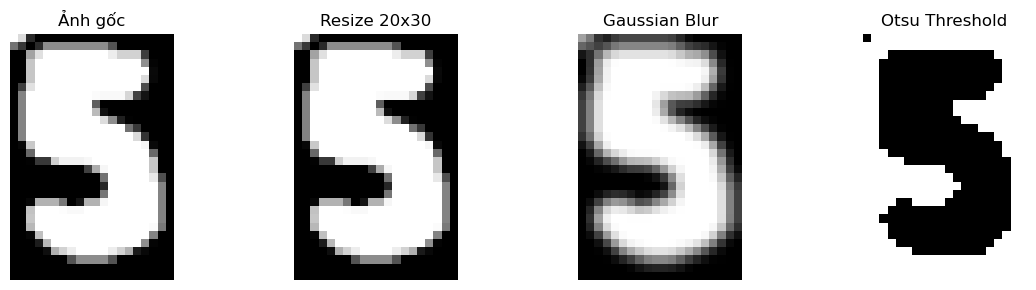

Ảnh mẫu: E:\Nhom A\data\char_images\Dieu_0108\char_00.png
Nhãn thật: 5
Vector đặc trưng: (1, 600)


In [4]:
sample_feature, sample_steps = preprocess_image(
    image_paths[0],
    return_steps=True
)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for ax, (title, image) in zip(axes, sample_steps.items()):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Ảnh mẫu:", image_paths[0])
print("Nhãn thật:", chr(y[0]))
print("Vector đặc trưng:", sample_feature.shape)


### Nhận xét tiền xử lý

- Resize bảo đảm mọi ảnh có cùng 600 đặc trưng.
- Gaussian Blur giảm các điểm nhiễu nhỏ.
- Otsu tự động chọn ngưỡng nhị phân.
- Việc thống nhất ký tự sáng trên nền tối giúp đặc trưng pixel đồng nhất hơn.
- Chia pixel cho 255 đưa dữ liệu về `[0, 1]` trước khi chuẩn hóa theo tập train.


## 4. Chia train/test theo từng lớp

Cách chia dưới đây giữ lại mẫu của từng nhãn trong cả train và test khi dữ liệu cho phép.


In [5]:
def stratified_split(y, test_size=0.25, seed=42):
    if not 0 < test_size < 1:
        raise ValueError("test_size phải nằm trong khoảng (0, 1).")

    rng = np.random.default_rng(seed)
    train_indices, test_indices = [], []

    for label in np.unique(y):
        indices = np.where(y == label)[0]
        rng.shuffle(indices)

        if len(indices) == 1:
            train_indices.extend(indices)
            continue

        test_count = max(1, int(round(len(indices) * test_size)))
        test_count = min(test_count, len(indices) - 1)

        test_indices.extend(indices[:test_count])
        train_indices.extend(indices[test_count:])

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return np.asarray(train_indices), np.asarray(test_indices)


TEST_SIZE = 0.25
SEED = 42

train_idx, test_idx = stratified_split(y, TEST_SIZE, SEED)

if len(test_idx) == 0:
    raise ValueError("Không có mẫu test. Cần bổ sung dữ liệu.")

print("Số mẫu train:", len(train_idx))
print("Số mẫu test:", len(test_idx))


Số mẫu train: 86
Số mẫu test: 29


## 5. Chuẩn hóa đặc trưng

SVM nhạy với thang đo đặc trưng. Mean và standard deviation chỉ được tính trên tập train để tránh rò rỉ dữ liệu.


In [6]:
def fit_scaler(X_train):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std < 1e-8] = 1.0
    return mean.astype(np.float32), std.astype(np.float32)


def transform_features(X_data, mean, std):
    return ((X_data - mean) / std).astype(np.float32)


scaler_mean, scaler_std = fit_scaler(X[train_idx])

X_train = transform_features(X[train_idx], scaler_mean, scaler_std)
X_test = transform_features(X[test_idx], scaler_mean, scaler_std)

y_train = y[train_idx]
y_test = y[test_idx]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (86, 600)
X_test: (29, 600)


## 6. Hàm huấn luyện và đánh giá SVM

SVM sử dụng:

- Loại mô hình: `C_SVC`
- Kernel: `RBF`
- `C`: mức phạt khi phân loại sai
- `gamma`: phạm vi ảnh hưởng của mỗi mẫu


In [7]:
def train_svm(X_train, y_train, C=1.0, gamma=0.01):
    svm = cv2.ml.SVM_create()
    svm.setType(cv2.ml.SVM_C_SVC)
    svm.setKernel(cv2.ml.SVM_RBF)
    svm.setC(float(C))
    svm.setGamma(float(gamma))
    svm.setTermCriteria(
        (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 5000, 1e-6)
    )

    ok = svm.train(
        X_train.astype(np.float32),
        cv2.ml.ROW_SAMPLE,
        y_train.astype(np.int32)
    )

    if not ok:
        raise RuntimeError("Huấn luyện SVM thất bại.")

    return svm


def predict_svm(svm, X_data):
    _, result = svm.predict(X_data.astype(np.float32))
    return result.ravel().astype(np.int32)


def classification_report_manual(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    rows = []

    for label in labels:
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        support = np.sum(y_true == label)

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall else 0.0
        )

        rows.append({
            "Nhãn": chr(label),
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "Support": int(support),
        })

    return pd.DataFrame(rows)


def confusion_matrix_manual(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    positions = {label: i for i, label in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), dtype=int)

    for true_label, predicted_label in zip(y_true, y_pred):
        matrix[positions[true_label], positions[predicted_label]] += 1

    return labels, matrix


def evaluate_svm(X_train, y_train, X_test, y_test, C, gamma):
    svm = train_svm(X_train, y_train, C=C, gamma=gamma)
    y_pred = predict_svm(svm, X_test)
    report = classification_report_manual(y_test, y_pred)

    return {
        "C": C,
        "Gamma": gamma,
        "Accuracy": float(np.mean(y_test == y_pred)),
        "Macro Precision": float(report["Precision"].mean()),
        "Macro Recall": float(report["Recall"].mean()),
        "Macro F1": float(report["F1-score"].mean()),
        "Đúng": int(np.sum(y_test == y_pred)),
        "Sai": int(np.sum(y_test != y_pred)),
        "model": svm,
        "predictions": y_pred,
        "report": report,
    }


## 7. Khảo sát tham số C và gamma

Thử 3 giá trị cho mỗi tham số:

```text
C = 0.1, 1, 10
gamma = 0.001, 0.01, 0.1
```

Tổng cộng 9 cấu hình được đánh giá trên cùng tập train/test.


In [8]:
C_VALUES = [0.1, 1.0, 10.0]
GAMMA_VALUES = [0.001, 0.01, 0.1]

experiment_rows = []
experiment_objects = {}

for C in C_VALUES:
    for gamma in GAMMA_VALUES:
        result = evaluate_svm(
            X_train, y_train,
            X_test, y_test,
            C=C,
            gamma=gamma
        )

        key = (C, gamma)
        experiment_objects[key] = result

        experiment_rows.append({
            "C": C,
            "Gamma": gamma,
            "Accuracy": result["Accuracy"],
            "Macro Precision": result["Macro Precision"],
            "Macro Recall": result["Macro Recall"],
            "Macro F1": result["Macro F1"],
            "Đúng": result["Đúng"],
            "Sai": result["Sai"],
        })

sweep_df = pd.DataFrame(experiment_rows)
sweep_df = sweep_df.sort_values(
    ["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(sweep_df.style.format({
    "C": "{:.3g}",
    "Gamma": "{:.3g}",
    "Accuracy": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}",
}))


,C,Gamma,Accuracy,Macro Precision,Macro Recall,Macro F1,Đúng,Sai
0,10,0.001,0.8276,0.7270,0.7500,0.7291,24,5
1,1,0.001,0.5172,0.3120,0.3452,0.3032,15,14
2,10,0.01,0.3103,0.1769,0.1786,0.1566,9,20
3,1,0.01,0.2759,0.0995,0.1429,0.1064,8,21
4,1,0.1,0.1724,0.0816,0.0893,0.0464,5,24
5,10,0.1,0.1724,0.0816,0.0893,0.0464,5,24
6,0.1,0.001,0.1379,0.0099,0.0714,0.0173,4,25
7,0.1,0.01,0.1379,0.0099,0.0714,0.0173,4,25
8,0.1,0.1,0.1379,0.0099,0.0714,0.0173,4,25


### Bảng Macro F1 theo C và gamma

Gamma,0.001000,0.010000,0.100000
C,,,
0.100000,0.0173,0.0173,0.0173
1.000000,0.3032,0.1064,0.0464
10.000000,0.7291,0.1566,0.0464


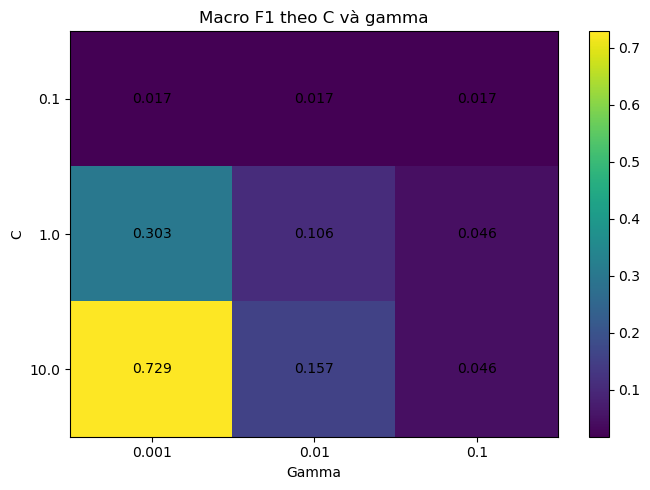

In [9]:
pivot_f1 = sweep_df.pivot(
    index="C",
    columns="Gamma",
    values="Macro F1"
)

display(Markdown("### Bảng Macro F1 theo C và gamma"))
display(pivot_f1.style.format("{:.4f}"))

plt.figure(figsize=(7, 5))
plt.imshow(pivot_f1.values, aspect="auto")
plt.title("Macro F1 theo C và gamma")
plt.xlabel("Gamma")
plt.ylabel("C")
plt.xticks(range(len(pivot_f1.columns)), pivot_f1.columns)
plt.yticks(range(len(pivot_f1.index)), pivot_f1.index)
plt.colorbar()

for i in range(pivot_f1.shape[0]):
    for j in range(pivot_f1.shape[1]):
        plt.text(
            j, i,
            f"{pivot_f1.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


## 8. Chọn cấu hình tốt nhất


In [10]:
best_row = sweep_df.iloc[0]
BEST_C = float(best_row["C"])
BEST_GAMMA = float(best_row["Gamma"])

best_result = experiment_objects[(BEST_C, BEST_GAMMA)]
best_predictions = best_result["predictions"]
best_report = best_result["report"]

summary_df = pd.DataFrame({
    "Thông số": [
        "Tổng số mẫu",
        "Số lớp",
        "Số mẫu train",
        "Số mẫu test",
        "Số chiều đặc trưng",
        "Test size",
        "Seed",
        "Kernel",
        "C tốt nhất",
        "Gamma tốt nhất",
        "Dự đoán đúng",
        "Dự đoán sai",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
    ],
    "Giá trị": [
        len(X),
        len(set(y)),
        len(train_idx),
        len(test_idx),
        X.shape[1],
        TEST_SIZE,
        SEED,
        "RBF",
        BEST_C,
        BEST_GAMMA,
        best_result["Đúng"],
        best_result["Sai"],
        f'{best_result["Accuracy"]:.4f} ({best_result["Accuracy"]:.2%})',
        f'{best_result["Macro Precision"]:.4f}',
        f'{best_result["Macro Recall"]:.4f}',
        f'{best_result["Macro F1"]:.4f}',
    ]
})

display(Markdown("### Thông số mô hình tốt nhất"))
display(summary_df)

display(Markdown("### Precision, Recall và F1-score từng lớp"))
display(best_report.style.format({
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
}))


### Thông số mô hình tốt nhất

,Thông số,Giá trị
0,Tổng số mẫu,115
1,Số lớp,18
2,Số mẫu train,86
3,Số mẫu test,29
4,Số chiều đặc trưng,600
5,Test size,0.25
6,Seed,42
7,Kernel,RBF
8,C tốt nhất,10.0
9,Gamma tốt nhất,0.001


### Precision, Recall và F1-score từng lớp

,Nhãn,Precision,Recall,F1-score,Support
0,0,0.7500,0.7500,0.7500,4
1,1,1.0000,1.0000,1.0000,4
2,2,1.0000,1.0000,1.0000,3
3,3,1.0000,1.0000,1.0000,2
4,4,1.0000,1.0000,1.0000,1
5,5,1.0000,0.7500,0.8571,4
6,6,1.0000,1.0000,1.0000,2
7,7,0.0000,0.0000,0.0000,1
8,8,0.0000,0.0000,0.0000,1
9,9,0.4286,1.0000,0.6000,3


## 9. Phân bố dữ liệu


,Nhãn,Số lượng
0,0,17
1,1,16
2,2,12
3,3,7
4,4,5
5,5,16
6,6,8
7,7,4
8,8,4
9,9,11


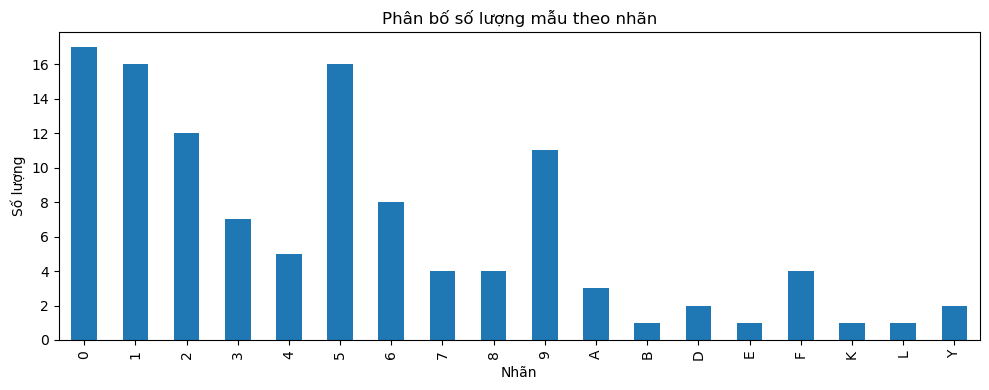

In [11]:
distribution_df = pd.DataFrame(
    sorted(Counter(chr(value) for value in y).items()),
    columns=["Nhãn", "Số lượng"]
)

display(distribution_df)

distribution_df.plot(
    kind="bar",
    x="Nhãn",
    y="Số lượng",
    legend=False,
    figsize=(10, 4)
)

plt.title("Phân bố số lượng mẫu theo nhãn")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()


## 10. Confusion Matrix


,0,1,2,3,4,5,6,7,8,9,A,D,F,Y
0,3,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,4,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,3,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,2,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,3,0,0,0,1,0,0,0,0
6,0,0,0,0,0,0,2,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,1,0,0,0,0
9,0,0,0,0,0,0,0,0,0,3,0,0,0,0


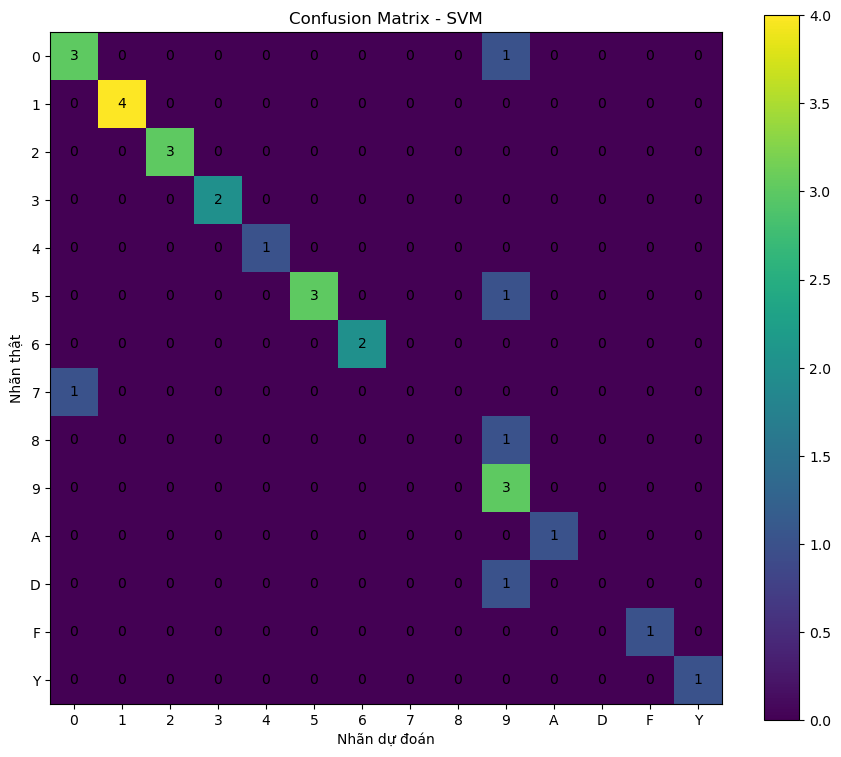

In [12]:
cm_labels, cm = confusion_matrix_manual(y_test, best_predictions)
cm_names = [chr(label) for label in cm_labels]
cm_df = pd.DataFrame(cm, index=cm_names, columns=cm_names)

display(cm_df)

plt.figure(figsize=(
    max(7, len(cm_names) * 0.65),
    max(6, len(cm_names) * 0.55)
))
plt.imshow(cm)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thật")
plt.xticks(range(len(cm_names)), cm_names)
plt.yticks(range(len(cm_names)), cm_names)
plt.colorbar()

for i in range(len(cm_names)):
    for j in range(len(cm_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 11. Phân tích các mẫu dự đoán sai


In [13]:
details_df = pd.DataFrame({
    "Ảnh": [str(image_paths[i]) for i in test_idx],
    "Nhãn thật": [chr(value) for value in y_test],
    "Dự đoán": [chr(value) for value in best_predictions],
    "Kết quả": [
        "Đúng" if true == pred else "Sai"
        for true, pred in zip(y_test, best_predictions)
    ],
})

wrong_df = details_df[details_df["Kết quả"] == "Sai"].copy()

print("Số mẫu dự đoán sai:", len(wrong_df))
display(wrong_df)


Số mẫu dự đoán sai: 5


,Ảnh,Nhãn thật,Dự đoán,Kết quả
2,E:\Nhom A\data\char_images\Tgmt_0066\char_06.png,8,9,Sai
5,E:\Nhom A\data\char_images\Dieu_0108\char_04.png,7,0,Sai
15,E:\Nhom A\data\char_images\greenpack_1582\char...,0,9,Sai
19,E:\Nhom A\data\char_images\Dieu_0108\char_00.png,5,9,Sai
25,E:\Nhom A\data\char_images\Tgmt_0066\char_02.png,D,9,Sai


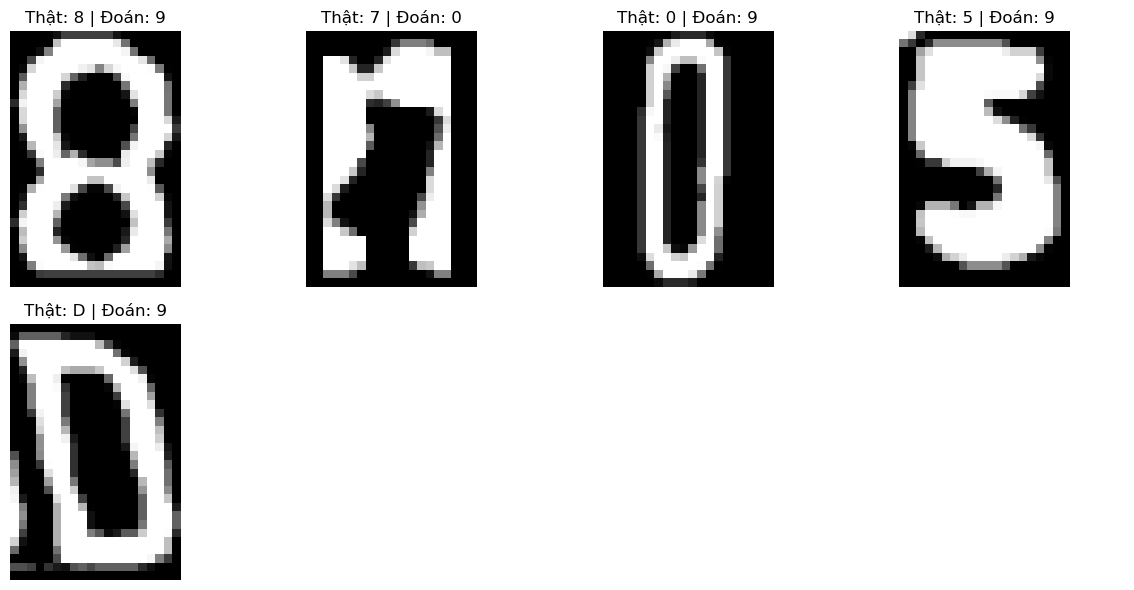

In [14]:
def show_wrong_predictions(max_images=12):
    wrong_positions = np.where(y_test != best_predictions)[0]

    if len(wrong_positions) == 0:
        print("Không có mẫu dự đoán sai.")
        return

    wrong_positions = wrong_positions[:max_images]
    columns = min(4, len(wrong_positions))
    rows = int(np.ceil(len(wrong_positions) / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(3 * columns, 3 * rows)
    )
    axes = np.asarray(axes).reshape(-1)

    for ax, position in zip(axes, wrong_positions):
        original_index = test_idx[position]
        image = cv2.imread(
            str(image_paths[original_index]),
            cv2.IMREAD_GRAYSCALE
        )

        ax.imshow(image, cmap="gray")
        ax.set_title(
            f"Thật: {chr(y_test[position])} | "
            f"Đoán: {chr(best_predictions[position])}"
        )
        ax.axis("off")

    for ax in axes[len(wrong_positions):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_wrong_predictions()


## 12. Huấn luyện mô hình cuối trên toàn bộ dữ liệu và lưu file

Sau khi chọn được `C` và `gamma`, scaler và SVM được huấn luyện lại bằng toàn bộ dữ liệu đã gán nhãn.


In [19]:
final_mean, final_std = fit_scaler(X)
X_all_scaled = transform_features(X, final_mean, final_std)

final_svm = train_svm(
    X_all_scaled,
    y,
    C=BEST_C,
    gamma=BEST_GAMMA
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
final_svm.save(str(SVM_MODEL))

np.savez(
    SVM_SCALER,
    mean=final_mean,
    std=final_std,
    C=BEST_C,
    gamma=BEST_GAMMA,
    width=CHAR_WIDTH,
    height=CHAR_HEIGHT,
)


In [20]:
from pathlib import Path

# Đặt thư mục lưu
MODEL_DIR = Path(r"E:\Nhom A\model_data")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Đặt tên file lưu
SVM_MODEL = MODEL_DIR / "svm_model.pkl"
SVM_SCALER = MODEL_DIR / "scaler.npz"

# Lưu mô hình
final_svm.save(str(SVM_MODEL))

# Lưu scaler và tham số
np.savez(
    SVM_SCALER,
    mean=final_mean,
    std=final_std,
    C=BEST_C,
    gamma=BEST_GAMMA,
    width=CHAR_WIDTH,
    height=CHAR_HEIGHT,
)

print("Đã lưu mô hình:", SVM_MODEL.resolve())
print("Đã lưu scaler:", SVM_SCALER.resolve())


Đã lưu mô hình: E:\Nhom A\model_data\svm_model.pkl
Đã lưu scaler: E:\Nhom A\model_data\scaler.npz


## 13. Dự đoán một thư mục ký tự

Thư mục dự đoán cần chứa các ảnh có tên dạng:

```text
char_0.png
char_1.png
char_2.png
...
```


In [16]:
def natural_char_order(path):
    digits = "".join(character for character in path.stem if character.isdigit())
    return int(digits) if digits else path.stem


def predict_folder_svm(
    folder,
    model_path=SVM_MODEL,
    scaler_path=SVM_SCALER
):
    folder = Path(folder)

    if not folder.exists():
        raise FileNotFoundError(f"Không tồn tại thư mục: {folder}")

    image_files = sorted(
        folder.glob("char_*.png"),
        key=natural_char_order
    )

    if not image_files:
        raise ValueError(
            f"Không tìm thấy file char_*.png trong {folder}"
        )

    if not Path(model_path).exists():
        raise FileNotFoundError(f"Chưa có model: {model_path}")

    if not Path(scaler_path).exists():
        raise FileNotFoundError(f"Chưa có scaler: {scaler_path}")

    svm = cv2.ml.SVM_load(str(model_path))
    scaler = np.load(scaler_path)
    mean = scaler["mean"]
    std = scaler["std"]

    predictions = []
    rows = []

    for image_file in image_files:
        feature = preprocess_image(image_file)
        scaled_feature = transform_features(feature, mean, std)
        predicted_code = int(predict_svm(svm, scaled_feature)[0])
        predicted_char = chr(predicted_code)

        predictions.append(predicted_char)
        rows.append({
            "Ảnh": str(image_file),
            "Ký tự dự đoán": predicted_char
        })

    predicted_text = "".join(predictions)
    result_df = pd.DataFrame(rows)

    display(Markdown(f"## Kết quả nhận diện: `{predicted_text}`"))
    display(result_df)

    columns = min(6, len(image_files))
    rows_count = int(np.ceil(len(image_files) / columns))

    fig, axes = plt.subplots(
        rows_count,
        columns,
        figsize=(2.5 * columns, 3 * rows_count)
    )
    axes = np.asarray(axes).reshape(-1)

    for ax, image_file, prediction in zip(
        axes,
        image_files,
        predictions
    ):
        image = cv2.imread(
            str(image_file),
            cv2.IMREAD_GRAYSCALE
        )
        ax.imshow(image, cmap="gray")
        ax.set_title(f"Dự đoán: {prediction}")
        ax.axis("off")

    for ax in axes[len(image_files):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return predicted_text, result_df


In [17]:
# Ví dụ sử dụng:
# predicted_text, prediction_table = predict_folder_svm(
#     folder=r"data/char_images/thu_muc_bien_so_can_du_doan"
# )


## 14. Mẫu nhận xét kết quả

Sau khi chạy notebook, có thể dùng mẫu sau và thay số liệu thực tế:

> Nhóm đã khảo sát 9 cấu hình SVM-RBF với `C` thuộc tập {0.1, 1, 10} và `gamma` thuộc tập {0.001, 0.01, 0.1}. Cấu hình tốt nhất là `C = ...`, `gamma = ...`, đạt Accuracy bằng `...` và Macro F1-score bằng `...`. Khi `C` quá nhỏ, mô hình chấp nhận nhiều lỗi hơn và có thể chưa học đủ ranh giới giữa các lớp. Khi `C` tăng, mô hình cố gắng phân loại đúng dữ liệu train mạnh hơn nhưng có nguy cơ overfitting. `Gamma` quá nhỏ tạo ranh giới quá trơn, còn gamma quá lớn làm vùng ảnh hưởng của mỗi mẫu quá hẹp. Vì vậy nhóm chọn cấu hình có Macro F1-score cao nhất làm mô hình cuối cùng.


## 15. Đối chiếu giả thuyết

- **Giả thuyết đúng:** nếu một cấu hình trung bình của `C` và `gamma` cho kết quả tốt nhất và SVM phân biệt tốt các lớp gần giống nhau.
- **Giả thuyết đúng một phần:** nếu SVM tốt ở một số lớp nhưng vẫn nhầm các ký tự có hình dạng rất giống nhau.
- **Giả thuyết sai:** nếu các cấu hình SVM không ổn định hoặc kém hơn đáng kể so với KNN.

Không cần cố chứng minh giả thuyết luôn đúng. Quan trọng là kết luận dựa trên số liệu.


## 16. Hạn chế và hướng phát triển

### Hạn chế

- Đặc trưng hiện tại vẫn là pixel thô.
- SVM phụ thuộc vào chất lượng ảnh tách ký tự.
- Dữ liệu mất cân bằng có thể làm Macro F1 giảm.
- Các ký tự gần giống như `0/O`, `1/I`, `5/S`, `8/B` dễ bị nhầm.
- Grid search hiện chỉ khảo sát một tập tham số nhỏ.

### Hướng phát triển

- Dùng HOG thay cho pixel thô.
- Tăng dữ liệu và cân bằng số mẫu từng lớp.
- Data augmentation: xoay nhẹ, dịch chuyển, thay đổi độ sáng.
- Mở rộng phạm vi `C` và `gamma`.
- So sánh định lượng trực tiếp SVM với KNN trên cùng split.
- Thử Linear SVM, Polynomial kernel hoặc CNN.


## 17. Kết luận

SVM-RBF là phương pháp phân loại có giám sát phù hợp cho bài toán nhận diện ký tự với dữ liệu vừa và nhỏ. Notebook này không chỉ gọi trực tiếp mô hình mà còn thể hiện toàn bộ quy trình tiền xử lý, chuẩn hóa, khảo sát tham số, đánh giá định lượng, phân tích lỗi và lưu mô hình để tái sử dụng.
